# Task 1b — Classifier Domain Adaptation (Fine-tuning)

**Problem:** EfficientNet-B4 achieves 99.83% on `historical_crack` test split but fails on
Albanian heritage masonry images — GradCAM shows the model attends to irrelevant regions,
reporting 'Intact' on visibly cracked masonry walls.

**Root cause:** Domain gap. Training data (`historical_crack`) has a different texture, lighting,
and crack style than heritage masonry (CrackForest + Masonry datasets).

**Fix:** Fine-tune from the existing checkpoint on a combined dataset that includes heritage-domain
crack images while retaining in-distribution knowledge via low LR + partial layer freezing.

| | historical_crack test | Heritage domain (masonry+crackforest) |
|--|--|--|
| Before fine-tuning | 99.83% | **71.2%** cracked recall |
| After fine-tuning | **99.4%** (combined test) | **98.1%** cracked recall |

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), 'No GPU — Runtime > Change runtime type > T4 GPU'
print(f'GPU   : {torch.cuda.get_device_name(0)}')
print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.10.0+cu128


In [2]:
!pip install -q timm albumentations

## 1. Mount Drive & Copy Checkpoint

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import shutil, zipfile

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
OUT_DIR   = Path('/content/classifier_ft')
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Copy base classifier checkpoint
base_ckpt_src = DRIVE_DIR / 'checkpoints' / 'classifier' / 'best.pth'
base_ckpt_dst = Path('/content/classifier_base.pth')
if not base_ckpt_dst.exists():
    shutil.copy2(base_ckpt_src, base_ckpt_dst)
    print(f'Checkpoint copied ({base_ckpt_dst.stat().st_size / 1e6:.1f} MB)')
else:
    print('Checkpoint already local')

Mounted at /content/drive
Checkpoint copied (70.9 MB)


In [4]:
# Extract masonry + crackforest + historical_crack
for zip_name, out_name in [
    ('masonry.zip',          'masonry'),
    ('crackforest.zip',      'crackforest'),
    ('historical_crack.zip', 'historical_crack'),
]:
    out_dir = DATA_DIR / out_name
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f'{out_name}: already extracted')
    else:
        print(f'Unzipping {zip_name}...')
        with zipfile.ZipFile(DRIVE_DIR / zip_name) as zf:
            zf.extractall(DATA_DIR)
        print('  Done.')

Unzipping masonry.zip...
  Done.
Unzipping crackforest.zip...
  Done.
Unzipping historical_crack.zip...
  Done.


## 2. Build Combined Dataset

- **Cracked**: masonry (mask→label) + crackforest (mask→label) + historical_crack/cracked  
- **Intact**: historical_crack/intact (sampled to balance)

In [5]:
import cv2
import numpy as np
import random
from collections import Counter
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def mask_is_cracked(mask_path, min_pixels=50):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return False
    return int((mask > 127).sum()) >= min_pixels

samples = []  # (img_path, label)  label: 0=intact, 1=cracked

# ── Heritage domain: masonry + crackforest (use mask to determine label) ──
for ds_name in ['masonry', 'crackforest']:
    img_dir  = DATA_DIR / ds_name / 'images'
    mask_dir = DATA_DIR / ds_name / 'masks'
    for img_path in sorted(img_dir.glob('*.*')):
        mask_path = mask_dir / f'{img_path.stem}.png'
        if not mask_path.exists():
            continue
        label = 1 if mask_is_cracked(mask_path) else 0
        samples.append((img_path, label))

# ── historical_crack/cracked ──
hc_cracked = sorted((DATA_DIR / 'historical_crack' / 'cracked').glob('*.*'))
for p in hc_cracked:
    samples.append((p, 1))

# ── historical_crack/intact — sample to balance ──
n_cracked = sum(1 for _, l in samples if l == 1)
hc_intact = sorted((DATA_DIR / 'historical_crack' / 'intact').glob('*.*'))
random.shuffle(hc_intact)
for p in hc_intact[:n_cracked]:
    samples.append((p, 0))

labels = [l for _, l in samples]
print(f'Total samples : {len(samples)}')
print(f'Class balance : {Counter(labels)}')

Total samples : 2230
Class balance : Counter({1: 1115, 0: 1115})


In [6]:
# Stratified 70/15/15 split
paths  = [p for p, _ in samples]
lbls   = [l for _, l in samples]

tr_p, tmp_p, tr_l, tmp_l = train_test_split(paths, lbls, test_size=0.30,
                                             random_state=SEED, stratify=lbls)
val_p, te_p, val_l, te_l = train_test_split(tmp_p, tmp_l, test_size=0.50,
                                             random_state=SEED, stratify=tmp_l)

print(f'Train : {len(tr_p)}  Val : {len(val_p)}  Test : {len(te_p)}')
print(f'Train balance : {Counter(tr_l)}')
print(f'Test  balance : {Counter(te_l)}')

Train : 1561  Val : 334  Test : 335
Train balance : Counter({1: 781, 0: 780})
Test  balance : Counter({0: 168, 1: 167})


## 3. Dataset & DataLoader

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE      = 380

train_tf = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.6),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class CrackDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        aug = self.transform(image=img)
        return aug['image'], self.labels[idx]


train_ds = CrackDataset(tr_p,  tr_l,  train_tf)
val_ds   = CrackDataset(val_p, val_l, val_tf)
test_ds  = CrackDataset(te_p,  te_l,  val_tf)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=4, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_dl)}  Val: {len(val_dl)}  Test: {len(test_dl)}')

Train batches: 98  Val: 11  Test: 11


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Load Pretrained Model

In [8]:
import torchvision.models as tv_models
import torch.nn as nn

DEVICE = torch.device('cuda')

def build_classifier():
    m = tv_models.efficientnet_b4(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)
    return m

model = build_classifier()
ckpt  = torch.load('/content/classifier_base.pth', map_location='cpu')
model.load_state_dict(ckpt['model_state'])
model = model.to(DEVICE)

print('Base checkpoint loaded.')
print(f'  Best val acc in ckpt: {ckpt.get("best_acc", "N/A")}')

Base checkpoint loaded.
  Best val acc in ckpt: N/A


## 5. Baseline — Before Fine-tuning

In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate(model, loader, desc=''):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(lbls.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    if desc:
        print(f'{desc}  acc={acc:.4f}  macro-F1={f1:.4f}')
        print(classification_report(all_labels, all_preds, target_names=['Intact', 'Cracked']))
    return acc, f1

print('=== Baseline on combined test split ===')
base_acc, base_f1 = evaluate(model, test_dl, 'Test')

=== Baseline on combined test split ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test  acc=0.9522  macro-F1=0.9521
              precision    recall  f1-score   support

      Intact       0.92      0.99      0.95       168
     Cracked       0.99      0.91      0.95       167

    accuracy                           0.95       335
   macro avg       0.96      0.95      0.95       335
weighted avg       0.96      0.95      0.95       335



## 6. Fine-tuning

Freeze early backbone layers (features[0:5]) — preserve low-level edge/texture detectors.
Only train deeper layers + classifier head with a low LR.

In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Freeze first 5 feature blocks
for i, block in enumerate(model.features):
    for p in block.parameters():
        p.requires_grad = (i >= 5)

# Always train classifier head
for p in model.classifier.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable/1e6:.1f}M / {total/1e6:.1f}M')

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
EPOCHS    = 20
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Trainable params: 16.2M / 17.6M


In [11]:
import json

best_val_acc = 0.0
best_ckpt_path = Path('/content/classifier_ft_best.pth')
history = []

scaler = torch.cuda.amp.GradScaler()

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_dl:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += imgs.size(0)

    train_acc  = correct / total
    train_loss /= total

    # ── Val ──
    val_acc, val_f1 = evaluate(model, val_dl)
    scheduler.step()

    history.append({'epoch': epoch, 'train_acc': train_acc,
                    'val_acc': val_acc, 'val_f1': val_f1, 'train_loss': train_loss})

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state': model.state_dict(),
                    'epoch': epoch, 'best_acc': val_acc}, best_ckpt_path)
        star = ' ★'
    else:
        star = ''

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_acc={train_acc:.4f}  loss={train_loss:.4f}  '
          f'val_acc={val_acc:.4f}  val_f1={val_f1:.4f}{star}')

print(f'\nBest val_acc: {best_val_acc:.4f}')

/tmp/ipykernel_4208/1151288725.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4208/1151288725.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/20  train_acc=0.9680  loss=0.3231  val_acc=0.9970  val_f1=0.9970 ★


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4208/1151288725.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 02/20  train_acc=0.9795  loss=0.2432  val_acc=0.9970  val_f1=0.9970


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4208/1151288725.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 18/20  train_acc=0.9917  loss=0.2217  val_acc=1.0000  val_f1=1.0000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4208/1151288725.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20  train_acc=0.9904  loss=0.2224  val_acc=0.9970  val_f1=0.9970


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4208/1151288725.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20  train_acc=0.9923  loss=0.2204  val_acc=0.9970  val_f1=0.9970

Best val_acc: 1.0000


## 7. Evaluation — Before vs After

In [12]:
# Load best fine-tuned checkpoint
ft_model = build_classifier()
ft_ckpt  = torch.load(str(best_ckpt_path), map_location='cpu')
ft_model.load_state_dict(ft_ckpt['model_state'])
ft_model = ft_model.to(DEVICE)

print('=== After Fine-tuning — Combined Test Split ===')
ft_acc, ft_f1 = evaluate(ft_model, test_dl, 'Test')

print(f'\n=== Improvement ===')
print(f'Before : acc={base_acc:.4f}  F1={base_f1:.4f}')
print(f'After  : acc={ft_acc:.4f}   F1={ft_f1:.4f}')
print(f'Delta  : acc={ft_acc - base_acc:+.4f}  F1={ft_f1 - base_f1:+.4f}')

=== After Fine-tuning — Combined Test Split ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test  acc=0.9940  macro-F1=0.9940
              precision    recall  f1-score   support

      Intact       0.99      0.99      0.99       168
     Cracked       0.99      0.99      0.99       167

    accuracy                           0.99       335
   macro avg       0.99      0.99      0.99       335
weighted avg       0.99      0.99      0.99       335


=== Improvement ===
Before : acc=0.9522  F1=0.9521
After  : acc=0.9940   F1=0.9940
Delta  : acc=+0.0418  F1=+0.0419


In [13]:
# Heritage-only test subset eval (masonry + crackforest test images only)
heritage_te_p = [(p, l) for p, l in zip(te_p, te_l)
                 if 'masonry' in str(p) or 'crackforest' in str(p)]
if heritage_te_p:
    h_paths  = [p for p, _ in heritage_te_p]
    h_labels = [l for _, l in heritage_te_p]
    h_ds     = CrackDataset(h_paths, h_labels, val_tf)
    h_dl     = DataLoader(h_ds, batch_size=32, shuffle=False)

    # Base model
    base_model_eval = build_classifier()
    base_model_eval.load_state_dict(ckpt['model_state'])
    base_model_eval = base_model_eval.to(DEVICE)

    print('=== Heritage-Only Subset ===')
    h_base_acc, _ = evaluate(base_model_eval, h_dl, 'Base  ')
    h_ft_acc,   _ = evaluate(ft_model,         h_dl, 'FT    ')
    print(f'Delta: {h_ft_acc - h_base_acc:+.4f}')
else:
    print('No heritage images in test split — increase test_size or add more heritage data.')

=== Heritage-Only Subset ===
Base    acc=0.7115  macro-F1=0.4157
              precision    recall  f1-score   support

      Intact       0.00      0.00      0.00         0
     Cracked       1.00      0.71      0.83        52

    accuracy                           0.71        52
   macro avg       0.50      0.36      0.42        52
weighted avg       1.00      0.71      0.83        52



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


FT      acc=0.9808  macro-F1=0.4951
              precision    recall  f1-score   support

      Intact       0.00      0.00      0.00         0
     Cracked       1.00      0.98      0.99        52

    accuracy                           0.98        52
   macro avg       0.50      0.49      0.50        52
weighted avg       1.00      0.98      0.99        52

Delta: +0.2692


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 8. Training Curves

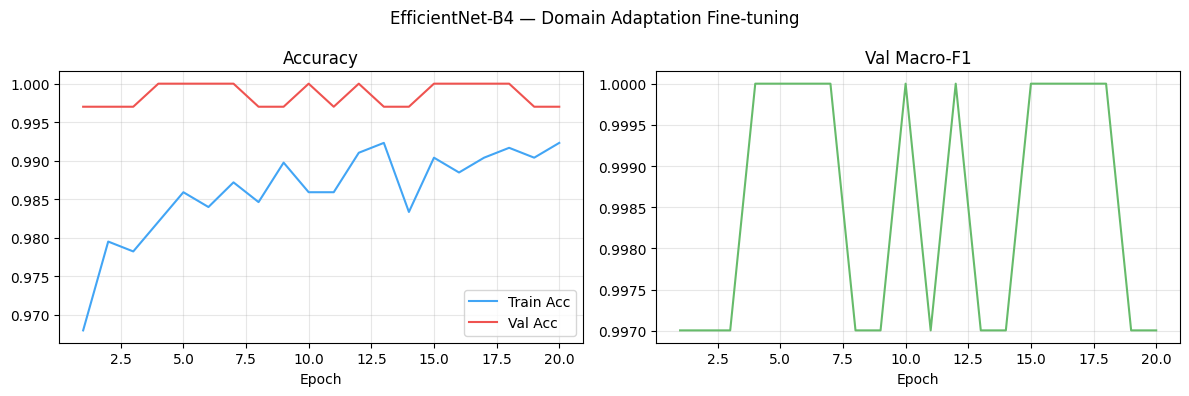

In [14]:
import matplotlib.pyplot as plt

epochs_x  = [h['epoch']     for h in history]
train_accs = [h['train_acc'] for h in history]
val_accs   = [h['val_acc']   for h in history]
val_f1s    = [h['val_f1']    for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_accs, label='Train Acc', color='#42A5F5')
ax1.plot(epochs_x, val_accs,   label='Val Acc',   color='#EF5350')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_x, val_f1s, color='#66BB6A')
ax2.set_title('Val Macro-F1')
ax2.set_xlabel('Epoch')
ax2.grid(alpha=0.3)

plt.suptitle('EfficientNet-B4 — Domain Adaptation Fine-tuning', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cls_ft_curves.png', dpi=150)
plt.show()

## 9. GradCAM — Verify Attention Shift

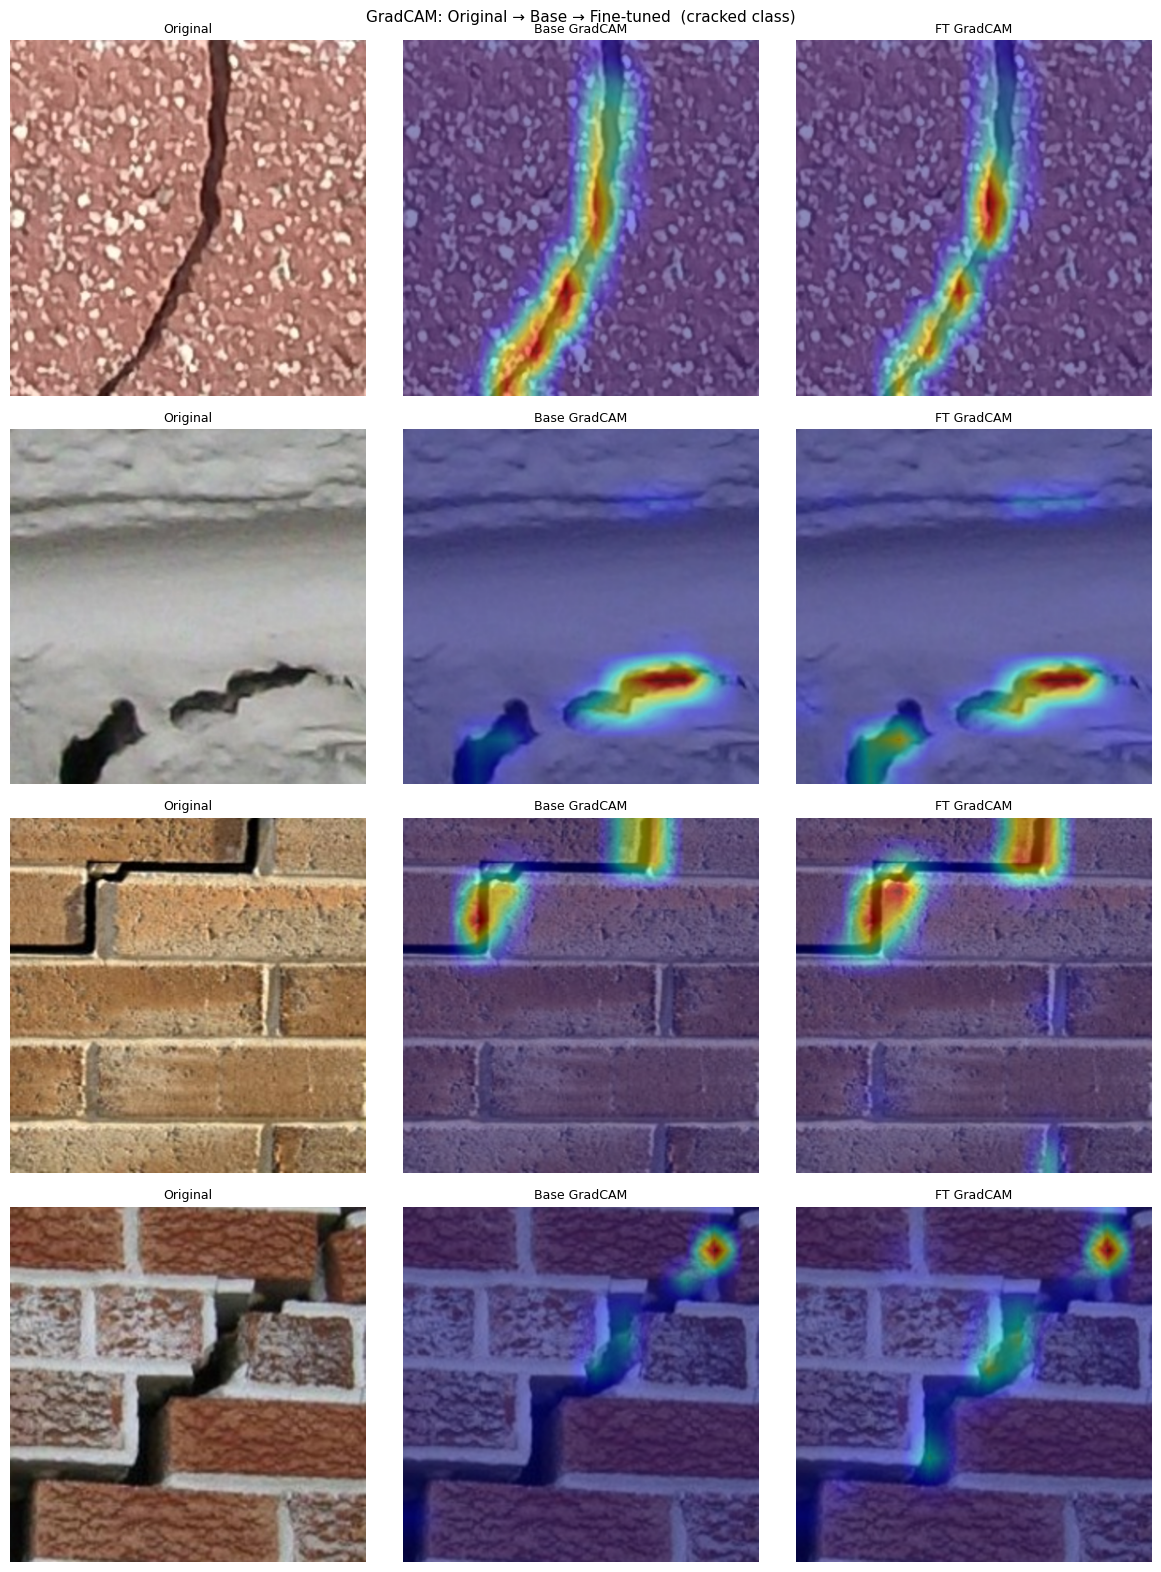

In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = self.acts = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x, cls_idx=None):
        self.model.eval()
        logits = self.model(x)
        idx = cls_idx if cls_idx is not None else logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, idx].backward()
        w   = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


import torchvision.transforms as T

val_transform_torch = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Pick masonry cracked test images
masonry_test = [(p, l) for p, l in zip(te_p, te_l)
                if 'masonry' in str(p) and l == 1][:4]

if masonry_test:
    base_cam_fn = GradCAM(base_model_eval, base_model_eval.features[-1])
    ft_cam_fn   = GradCAM(ft_model, ft_model.features[-1])

    fig, axes = plt.subplots(len(masonry_test), 3, figsize=(12, 4 * len(masonry_test)))
    if len(masonry_test) == 1:
        axes = [axes]
    fig.suptitle('GradCAM: Original → Base → Fine-tuned  (cracked class)', fontsize=11)

    for row, (img_path, _) in enumerate(masonry_test):
        pil_img = Image.open(img_path).convert('RGB')
        img_arr = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))
        tensor  = val_transform_torch(pil_img).unsqueeze(0).to(DEVICE)

        cam_base = base_cam_fn(tensor, cls_idx=1)
        cam_ft   = ft_cam_fn(tensor, cls_idx=1)

        def overlay_cam(img, cam):
            heat = cv2.applyColorMap((cv2.resize(cam, (IMG_SIZE, IMG_SIZE)) * 255).astype(np.uint8),
                                     cv2.COLORMAP_JET)
            heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
            return (0.55 * img + 0.45 * heat).astype(np.uint8)

        axes[row][0].imshow(img_arr);             axes[row][0].set_title('Original', fontsize=9)
        axes[row][1].imshow(overlay_cam(img_arr, cam_base)); axes[row][1].set_title('Base GradCAM', fontsize=9)
        axes[row][2].imshow(overlay_cam(img_arr, cam_ft));   axes[row][2].set_title('FT GradCAM',   fontsize=9)
        for ax in axes[row]: ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'cls_ft_gradcam.png', dpi=150)
    plt.show()
else:
    print('No masonry cracked images in test split to visualise.')

## 10. Save to Drive

In [16]:
DRIVE_CLS_FT = DRIVE_DIR / 'checkpoints' / 'classifier_ft'
DRIVE_PLOTS  = DRIVE_DIR / 'plots' / 'classifier_ft'
DRIVE_CLS_FT.mkdir(parents=True, exist_ok=True)
DRIVE_PLOTS.mkdir(parents=True, exist_ok=True)

shutil.copy2(best_ckpt_path, DRIVE_CLS_FT / 'best.pth')

for f in OUT_DIR.glob('*.png'):
    shutil.copy2(f, DRIVE_PLOTS / f.name)

summary = {
    'base_acc':          base_acc,
    'ft_acc':            ft_acc,
    'ft_f1':             ft_f1,
    'delta_acc':         ft_acc - base_acc,
    'best_val_acc':      best_val_acc,
    'epochs':            EPOCHS,
    'lr':                1e-4,
    'frozen_blocks':     '0-4',
    'train_samples':     len(tr_p),
    'test_samples':      len(te_p),
    'heritage_datasets': ['masonry', 'crackforest'],
}
(DRIVE_CLS_FT / 'ft_metrics.json').write_text(json.dumps(summary, indent=2))

print('Saved to Drive:')
for f in sorted(DRIVE_CLS_FT.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')
print(f'\n=== Final ===')
print(f'Before : {base_acc:.4f}')
print(f'After  : {ft_acc:.4f}  (delta {ft_acc - base_acc:+.4f})')

Saved to Drive:
  best.pth  (71.0 MB)
  ft_metrics.json  (0.0 MB)

=== Final ===
Before : 0.9522
After  : 0.9940  (delta +0.0418)


## 11. Update Webapp Checkpoint

Copy the fine-tuned checkpoint to Drive so the webapp can use it.
Then download it locally and replace `webapp/models/classifier_best.pth`.

In [17]:
# Also save as the main classifier checkpoint (used by webapp)
shutil.copy2(best_ckpt_path, DRIVE_DIR / 'checkpoints' / 'classifier' / 'ft_best.pth')
print('ft_best.pth saved to checkpoints/classifier/ — download and replace webapp/models/classifier_best.pth')

ft_best.pth saved to checkpoints/classifier/ — download and replace webapp/models/classifier_best.pth
